# Marlim 3 - Tutoriais em Python

# Gas lift

CVPO - 01/2025

Neste notebook, damos continuidade ao caso base desenvolvido no tutorial anterior, que abordou a análise nodal do escoamento, e realizamos simulações de injeção de gás na linha de produção, procedimento usado na técnica de elevação artificial denominada [*gas lift*](https://en.wikipedia.org/wiki/Gas_lift). Analisamos conceitos como curva de desempenho, acoplamento térmico entre linhas de produção e serviço e escoamento estrangulado em válvulas.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import marlim3
import copy

## Introdução

No contexto da disciplina de Elevação e Escoamento (EE), a elevação artificial compreende um conjunto de técnicas aplicadas quando a pressão do reservatório não é suficiente para que o fluido atinja a plataforma com a vazão desejada. Dentre os métodos disponíveis, o mais utilizado é o *gas lift* contínuo, por ser simples (sem mecanismos giratórios e vibrantes que poderiam ocasionar falhas) e aplicável a poços de altas vazões. Esse método consiste na injeção de gás na coluna de produção, com o objetivo de reduzir a massa específica média do fluido ao longo do escoamento. Essa redução minimiza a parcela da perda de carga associada à hidrostática (resistência à gravidade). Como, na maioria das condições de interesse, a perda de carga hidrostática representa a maior fração da resistência total ao escoamento, o *gas lift* resulta em uma diminuição da perda de carga total. Isso, por sua vez, reduz a pressão de fundo do poço e permite um aumento da vazão produzida. Para mais detalhes sobre os fundamentos da técnica de *gas lift*, recomenda-se a consulta ao Capítulo 6 de [ANDREOLLI (2016)](https://www.amazon.com.br/Introdu%C3%A7%C3%A3o-Eleva%C3%A7%C3%A3o-Escoamento-Monof%C3%A1sico-Multif%C3%A1sico/dp/857193388X).

No [Marlim 3](https://github.com/petrobras/marlim3), há a possibilidade de modelar a injeção de gás para fins de elevação artificial de duas maneiras:

1. Utilizando uma fonte do tipo `fonteGas`. Essa é a alternativa mais simples, que requer apenas a definição das condições do gás no ponto de injeção na linha de produção.
2. Adicionando ao sistema uma linha de serviço com válvula de *gas lift* (`fonteGasLift`). Essa alternativa é mais complexa e permite modelar o sistema com maior detalhamento, incluindo a válvula de *gas lift*, as propriedades do gás ao longo do escoamento e a troca térmica entre as linhas de produção e serviço. Além disso, as condições do gás são definidas no ponto de injeção da plataforma.

Neste tutorial apresentamos as duas possibilidades, começando pela mais simples.

## Importando o caso base

Importaremos como caso base o caso que foi exportado no tutorial anterior, sobre análise nodal do escoamento:

In [2]:
caso_base = marlim3.Tramo()
caso_base.from_json('caso_base1_tutoriais.json')

## Adicionando uma fonte de gás

Nesta seção, adicionamos uma fonte de gás ao caso base para simular a injeção de maneira simplificada. Para isso, também é necessário definir um objeto do tipo `fluidoGas`, representando o gás a ser produzido pela fonte.

In [3]:
fluido_gas = {
    "densidadeGas": 0.7
}

fonte_gas = {
    "id": 0,
    "comprimentoMedido": 200, #m
    "tempo": [0], #s
    "temperatura": [87], #degC,
    "vazaoGas": [1.5e5] #sm3/d
} 

caso_base.fluidoGas = fluido_gas
caso_base.fonteGas = [fonte_gas]

## Simulando!!

In [4]:
caso_base.simular()

*******************************************************************************
                                  UFA!!!!!!!!                                  
                   Infeliz e o espirito ansioso pelo futuro.                    
                              Seneca do Mindfulness                                     
*******************************************************************************
ARQUIVO DE LOG: simulacao.log



In [5]:
caso_base.resultados['perfilProducao']

Comprimento (m) Fronteira F  Comprimento (m) Centro Volume C  \
Tempo (s)                                                                    
0         0                             0                               50   
          1                           100                              150   
          2                           200                              250   
          3                           300                              350   
          4                           400                              450   
          5                           500                              550   
          6                           600                              650   
          7                           700                              750   
          8                           800                              850   
          9                           900                              950   
          10                         1000                             1050   
          11                         1100                             1150   
          12                         1200                             1250   
          13                         1300                             1350   
          14                         1400                             1450   
          15                         1500                             1550   
          16                         1600                             1650   
          17                         1700                             1750   
          18                         1800                             1850   
          19                         1900                             1950   
          20                         2000                             2050   
          21                         2100                             2150   
          22                         2200                             2250   
          23                         2300                             2350   
          24                         2400                             2450   
          25                         2500                             2550   
          26                         2600                             2650   
          27                         2700                             2750   
          28                         2800                             2850   
          29                         2900                             2950   

              Pressao (kgf/cm2) C  Temperatura (C) C  Holdup de liquido (-) C  \
Tempo (s)                                                                       
0         0            125.456926          90.000000                 0.902716   
          1            117.330752          89.762224                 0.908060   
          2            109.672760          89.367960                 0.743806   
          3            102.699343          88.977870                 0.722461   
          4             95.884788          88.562525                 0.700038   
          5             89.238931          88.122256                 0.676717   
          6             82.770813          87.657546                 0.652456   
          7             76.489102          87.168920                 0.627307   
          8             70.401463          86.656927                 0.601339   
          9             64.514095          86.095377                 0.574667   
          10            61.408367          85.457656                 0.532243   
          11            60.992999          85.316695                 0.520887   
          12            60.578747          85.176124                 0.518935   
          13            60.162156          85.035890                 0.516970   
          14            59.743172          84.895892                 0.514985   
          15            59.321745          84.756130                 0.512979   
          16            58.897820          84.616605       

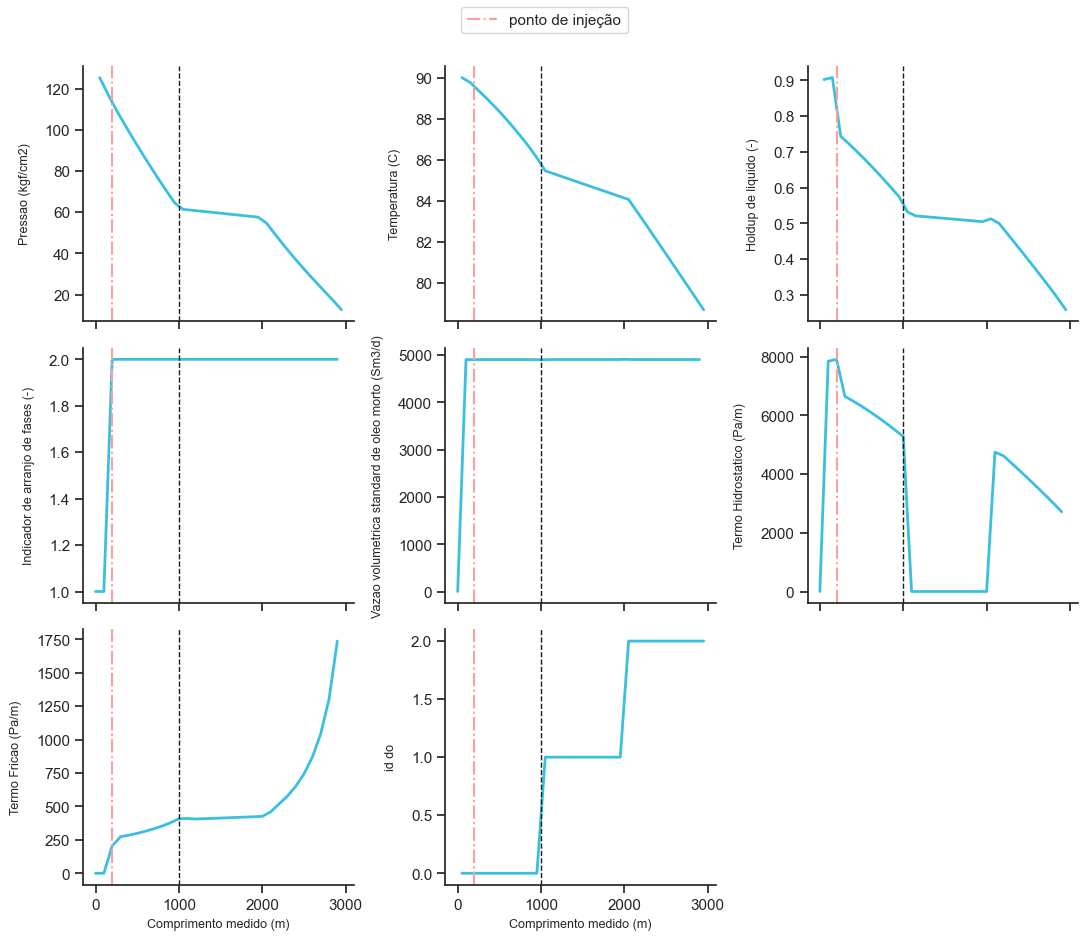

In [6]:
fig, axes = caso_base.plotar_perfis(indicar_anm=True)

for ax in axes:
    ax.axvline(caso_base.fonteGas[0]['comprimentoMedido'], 
               c='r', label='ponto de injeção', ls='-.')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center');

## Faça você também!

**1**. Compare os resultados apresentados acima com os resultados da simulação do caso base do tutorial anterior (`analise_nodal.ipynb`). Identifique as diferenças e observe como as variáveis se comportam quando o gás é introduzido no sistema.

**2**. Varie alguns parâmetros da injeção, como posição, vazão, densidade e temperatura. Analise os impactos dessas alterações nos perfis das variáveis (dica: use a classe `Cenarios` do pacote `marlim3`, como demonstrado no tutorial `comparacao_horizontal_vertical.ipynb`).

**3**. Há um limite para o aumento de produtividade causado pela injeção de gás no sistema? Reflita sobre como isso se relaciona com a última figura que geramos no tutorial anterior (`analise_nodal.ipynb`).

## Otimização da produção

No exercício final da seção anterior, você refletiu sobre o limite de aumento na produtividade devido à injeção de gás. Agora, iremos explorar esse limite de forma computacional, calculando a vazão de gás injetada que maximiza a vazão de líquido produzida. Para isso, utilizaremos um método numérico de otimização. Essa análise é designada como curva de desempenho do *gas lift*, utilizada para analisar a relação entre a vazão de gás injetada e a vazão de líquido produzida, ajudando a identificar o ponto ótimo de operação.

Vamos definir uma função objetivo que aceite a vazão de gás, efetue a simulação e retorne a vazão de líquido produzida:

In [7]:
caso_otim = copy.deepcopy(caso_base)
caso_otim.configuracaoInicial['saidaClassica'] = False

def fObj (vazao_gas):

    caso_otim.fonteGas[0]['vazaoGas'] = [vazao_gas]
    caso_otim.simular()

    return -caso_otim.resultados['perfilProducao'].loc[0,'Vazao volumetrica standard de oleo morto (Sm3/d) F'].iloc[-1]

A função retorna o negativo da vazão pois usaremos um método numérico de minimização. Na célula a seguir, utilizamos a função objetivo para efetuar a otimização e plotamos o resultado na curva de desempenho de *gas lift*:





















































CPU times: total: 2.19 s
Wall time: 2min 13s


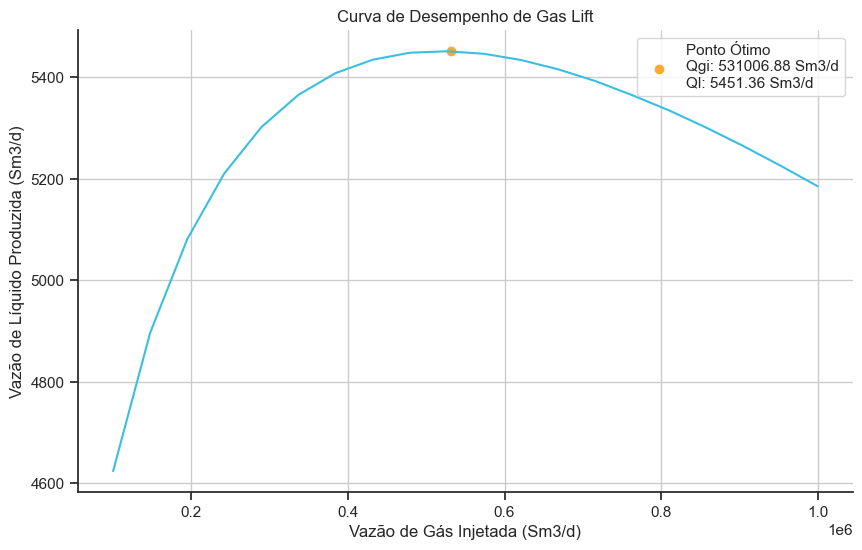

In [8]:
%%time

# importando otimizador
from scipy.optimize import minimize_scalar

# intervalo de busca de vazão
intervalo = (1e5, 1e6) #sm3/d

# otimizando!!
resultado = minimize_scalar(fObj, bounds=intervalo, method='bounded')

# resultado ótimo
vazao_gas_otima = resultado.x
vazao_liquido_otima = -resultado.fun

# gerando pontos para o gráfico
vazoes_gas = np.linspace(intervalo[0], intervalo[1], 20)
vazoes_liquido = []
for vazao_gas in vazoes_gas:
    caso_otim.fonteGas[0]['vazaoGas'] = [vazao_gas]
    caso_otim.simular()
    vazao_liquido_produzida = caso_otim.resultados['perfilProducao'].loc[0, 'Vazao volumetrica standard de oleo morto (Sm3/d) F'].iloc[-1]
    vazoes_liquido.append(vazao_liquido_produzida)

# plotando a função objetivo e o ponto ótimo
plt.figure(figsize=(10, 6))
plt.plot(vazoes_gas, vazoes_liquido, color='#39C0E0')
plt.scatter(vazao_gas_otima, vazao_liquido_otima, color='#FFA933', label=f"Ponto Ótimo\nQgi: {vazao_gas_otima:.2f} Sm3/d\nQl: {vazao_liquido_otima:.2f} Sm3/d")
plt.xlabel("Vazão de Gás Injetada (Sm3/d)")
plt.ylabel("Vazão de Líquido Produzida (Sm3/d)")
plt.title("Curva de Desempenho de Gas Lift")
plt.legend()
plt.grid()

Observe que, a partir do ponto ótimo, um aumento na vazão de gás injetada resulta em uma redução na vazão de líquido produzida. Isso ocorre porque, com altas vazões de gás, o aumento do termo de fricção da perda de carga é tão significativo que supera a redução do termo hidrostático.

Na prática, diversos fatores adicionais influenciam a definição do ponto de operação, como os custos associados à compressão do gás, a disponibilidade de gás no mercado consumidor e as dificuldades relacionadas à sua exportação. Dessa forma, o ponto de maior retorno econômico pode não coincidir com o ponto de maior vazão de líquido produzida. Para mais detalhes, consultar [ANDREOLLI (2016)](https://www.amazon.com.br/Introdu%C3%A7%C3%A3o-Eleva%C3%A7%C3%A3o-Escoamento-Monof%C3%A1sico-Multif%C3%A1sico/dp/857193388X).

## Faça você também!

**1.** Plote várias curvas de desempenho de *gas lift* no mesmo gráfico, variando parâmetros como BSW e diâmetro da linha.

## Adicionando linha de serviço e válvula de *gas lift*

A abordagem apresentada na seção anterior é suficiente para estudos simples relacionados ao aumento da produtividade do poço por meio da injeção de gás. No entanto, para uma representação mais detalhada dos fenômenos físicos associados à injeção de gás, é preciso adicionar uma linha de serviço e uma válvula de *gas lift* (VGL) ao modelo.

O primeiro passo para isso é desativar a fonte de gás colocada anteriormente:

In [9]:
caso_base_vgl = copy.deepcopy(caso_base)

caso_base_vgl.fonteGas[0]['ativo'] = False

### Atualização da linha de produção

#### Adicionando nova seção transversal para o trecho de poço sem acoplamento

A linha de serviço se estende desde a plataforma até o ponto de injeção, onde está localizada a VGL. Abaixo desse ponto, não há linha de serviço, e, consequentemente, a seção transversal do poço nessa região consistirá em apenas uma camada. Assim, será necessário adicionar mais um elemento ao vetor `secaoTransversal`, representando o corte correspondente a essa área.

Vamos visualizar como está o conjunto de seções transversais até o momento:

In [10]:
caso_base_vgl.exibir_tabela('secaoTransversal')

Vamos copiar a primeira seção, correspondente ao poço, e manter apenas a primeira camada, correspondente à camada de aço interna:

In [11]:
secao_producao_poco2 = copy.deepcopy(caso_base_vgl.secaoTransversal[0])

secao_producao_poco2['id'] = 2
secao_producao_poco2['rotulo'] = 'Corte do poço - trecho sem acoplamento'
secao_producao_poco2['camadas'] = [secao_producao_poco2['camadas'][0]]

caso_base_vgl.secaoTransversal.append(secao_producao_poco2)

#### Adicionando novo duto de produção para o trecho de poço sem acoplamento

Com a seção transversal já disponível, podemos criar um novo duto de produção para o trecho entre o fundo do poço e a VGL. Além disso, será necessário atualizar o outro trecho do poço (entre a VGL e o leito marinho) para as novas configurações.

Vamos visualizar como está o conjunto de dutos de produção até o momento:

In [12]:
caso_base_vgl.exibir_tabela('dutosProducao')

O que precisamos fazer é:

- desmembrar o duto do poço em dois outros dutos, um de 0 a 200 m que corresponde ao trecho sem acoplamento (do fundo do poço até a VGL) e o outro de 200 a 800 m que corresponde ao trecho acoplado à linha de serviço (da VGL até o leito marinho);

- ligar o acoplamento térmico no trecho correspondente;

- modificar as condições ambiente (temperatura externa) no trecho sem acoplamento. No caso do trecho acoplado, as condições ambiente devem ser informadas na linha de serviço, não na de produção.

A parte mais complicada é configurar as condições ambiente, tanto na linha de produção quanto na linha de serviço, para que corresponda àquela especificada no caso base sem linha de serviço. Para auxiliar nessa tarefa, definimos uma função que retorne a temperatura da formação para respeitar o que foi especificado no caso anterior:

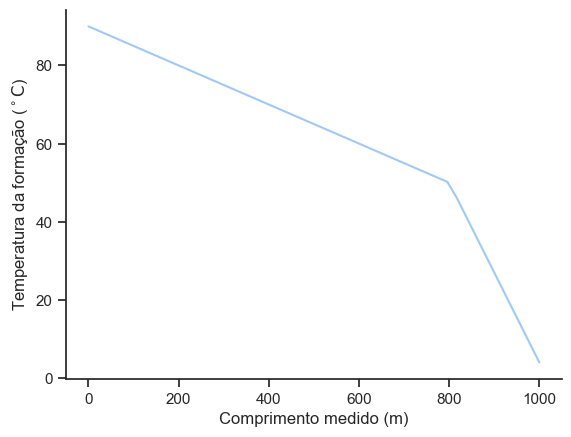

In [13]:
def T_amb_poco (x):
    if x<=800:
        return -.05*x+90
    else:
        #return -0.23*x + 234
        return 50-.23*(x-800)

X = np.linspace(0,1000)

plt.plot(X,[T_amb_poco(x) for x in X]);
plt.xlabel('Comprimento medido (m)')
plt.ylabel(r'Temperatura da formação ($^\circ\mathrm{C}$)');

Feito isso, podemos definir o trecho sem acoplamento (entre 0 e 200m) e adicioná-lo à lista de dutos de produção (na primeira posição, de acordo com a ordem de preenchimento, que segue o sentido do escoamento):

In [14]:
duto_producao_sem_acoplamento = {
  'id': 3,
  'rotulo': 'Poço - Trecho sem acoplamento',
  'idCorte': 2, # nova seção transversal definida acima, contendo somente a camada interna de aço
  'idFormacao': 0, #formação original
  'angulo': np.pi/2,
  'discretizacao': [{'nCelulas': 2, 'comprimento': 100}]}

duto_producao_sem_acoplamento['condicoesIniciais'] = {'compInter': [0,1], 'tempExterna': [T_amb_poco(0), T_amb_poco(200)]}

caso_base_vgl.dutosProducao.insert(0, duto_producao_sem_acoplamento)

O próximo passo é modificar o segundo duto para que tenha o comprimento de 800 m e considere o acoplamento térmico:

In [15]:
caso_base_vgl.dutosProducao[1]['discretizacao'] = [{'nCelulas': 8, 'comprimento': 100}]

caso_base_vgl.dutosProducao[1]['acoplamentoTermico'] = 1
del caso_base_vgl.dutosProducao[1]['idFormacao']

Agora nossa lista de dutos de produção está pronta:

In [16]:
caso_base_vgl.exibir_tabela('dutosProducao')

### Adicionando linha de serviço

A linha de serviço será constituída de três dutos, correspondentes aos trechos poço, flowline e riser, de maneira semelhante à linha de produção. No entanto, há duas importantes diferenças:

- a ordem de preenchimento na linha de serviço é da plataforma para o poço (seguindo o sentido do escoamento de injeção);
- o último duto de serviço, correspondente ao trecho de poço, terá geometria anular, acoplada ao primeiro duto de produção.
- 
O primeiro passo é ativar a linha de serviço em [`configuracaoInicial`](https://petrobrasbr.sharepoint.com/teams/Marlim3/SitePages/configuracaoInicial.aspx):

In [17]:
caso_base_vgl.configuracaoInicial['linhaGas'] = True

Agora vamos definir as seções transversais que comporão esses dutos. Para a seção transversal do anular, será preciso definir os diâmetros interno e externo com base nas informações da seção transversal original do poço:

In [18]:
diametro_interno_coluna = caso_base.secaoTransversal[0]['diametroInterno']

# diametro interno do anular
# diametro interno da coluna mais duas vezes a espessura radial da primeira camada de aço
diametro_interno_anular = diametro_interno_coluna+2*caso_base.secaoTransversal[0]['camadas'][0]['espessura'] 

# diametro externo do anular
# diametro interno do anular mais duas vezes a espessura radial da segunda camada (fluido de completação), 
# que no duto de serviço corresponde à região de escoamento do anular
diametro_externo_anular = diametro_interno_anular+ 2*caso_base.secaoTransversal[0]['camadas'][1]['espessura']

Definidas as camadas, podemos criar as seções transversais:

In [19]:
secao_servico_flowline_riser = {
    "id": 3,
    'rotulo': 'Corte da flowline+riser [SERVIÇO]',
    "diametroInterno": 5*0.0254, #m
    "rugosidade": 0.183e-3, #m
    "camadas": caso_base.secaoTransversal[1]['camadas'] # 1'' de aço + 1'' de isolante, definida no tutorial anterior sobre análise nodal
}

secao_servico_poco = {
    "id": 4,
    'rotulo': 'Corte do poço [SERVIÇO]',
    "anular": True,
    "diametroInterno": diametro_interno_anular, #m
    "diametroExterno": diametro_externo_anular, #m
    "rugosidade": 0.183e-3, #m
    "camadas": caso_base.secaoTransversal[0]['camadas'][-2:]
}

caso_base_vgl.secaoTransversal.append(secao_servico_flowline_riser)
caso_base_vgl.secaoTransversal.append(secao_servico_poco)

Definidas as seções transversais, podemos criar os três dutos correspondentes:

In [20]:
ncel = 10

comprimento_total = 1000 #m

discretizacao = {
    "nCelulas": ncel,
    "comprimento": comprimento_total/ncel #m
}

condicoes_mar_subida = {
          "compInter": [0, 1],
          "tempExterna": [20, 4], #degC
          "velExterna": [1, 0.1], #m/s

}

riser_servico = {
        "id": 0,
        "rotulo": "Riser [SERVIÇO]",
        "idCorte": 2, #id da seção transversal de flowline+riser definida anteriormente
        "ambienteExterno": 1, #água do mar
        "angulo": -np.pi/2, #rad
        "discretizacao": [discretizacao], #discretização definida logo acima
        "condicoesIniciais": condicoes_mar_subida, #condições definidas logo acima
        "acoplamentoTermico": 0 # sem acoplamento

}

In [21]:
ncel = 10

comprimento_total = 1000 #m

discretizacao = {
    "nCelulas": ncel,
    "comprimento": comprimento_total/ncel #m
}

condicoes_leito_marinho = {
          "compInter": [0, 1],
          "tempExterna": [4, 4], #degC
          "velExterna": [0.1, 0.1], #m/s

}

linha_servico = {
        "id": 1,
        "rotulo": "Flowline [SERVIÇO]",
        "idCorte": 2, #id da seção transversal de flowline+riser definida anteriormente
        "ambienteExterno": 1, #água do mar
        "angulo": 0, #rad
        "discretizacao": [discretizacao], #discretização definida logo acima
        "condicoesIniciais": condicoes_leito_marinho, #condições definidas logo acima
        "acoplamentoTermico": 0 # sem acoplamento
}

In [22]:
ncel = 10

comprimento_total = 1000-200 #m

discretizacao = {
    "nCelulas": ncel,
    "comprimento": comprimento_total/ncel #m
}

condicoes_formacao_servico = {
          "compInter": [0, 200/800, 1], 
          "tempExterna": [4, 50, T_amb_poco(200)] #degC #90-(200/800)*(90-50)]
}

anular_coluna_servico = {
        "id": 2,
        "rotulo": "Anular do Poço [SERVIÇO]",
        "idCorte": 3, 
        "idFormacao": 0, #id da formação definida anteriormente
        "angulo": -np.pi/2, #rad; negativo pois desce!!
        "discretizacao": [discretizacao], #discretização definida logo acima
        "condicoesIniciais": condicoes_formacao_servico, #condições definidas logo acima
        "acoplamentoTermico": 1 # com acoplamento
} 

Definidos os três dutos, podemos adicioná-los ao campo `dutosServico`:

In [23]:
caso_base_vgl.dutosServico = [riser_servico, linha_servico, anular_coluna_servico]

Visualizando a tabela de dutos de serviço:

In [24]:
caso_base_vgl.exibir_tabela('dutosServico')

Visualizando a geometria:

In [25]:
caso_base_vgl.plotar_geometria()

### Válvula de *gas lift*

A válvula de *gas lift* deve ser definida no objeto [`fonteGasLift`](https://petrobrasbr.sharepoint.com/teams/Marlim3/SitePages/fonteGasLift.aspx). Usaremos primeiramente uma válvula de orifício (depois compararemos com outro caso utilizando válvula Venturi).

In [26]:
vgl = {
      "id": 0,
      "comprimentoMedidoProducao": 200, #m
      "comprimentoMedidoServico": 2800, #m
      "tipoValvula": 0, #orifício
      "diametroOrificio": 0.005, #m
      "frecupera": 0.0,
      "razaoArea": 0.1
}

caso_base_vgl.fonteGasLift = [vgl]

### Condição de contorno da injeção de gás

Também é necessário definir as condições de contorno da injeção de gás no compressor da plataforma:

In [27]:
cc_inj = {
      "tipoCC": 1, #vazão de injeção
      "tempo": [0], #s
      "temperatura": [40], #degC
      "vazaoGas": [1.5e5], #sm3/d
}

caso_base_vgl.gasInj = cc_inj

### Especificação da saída da simulação na linha de serviço

In [28]:
vars_saida_list = ["pressao", 
                   "temperatura",
                   "hidro",
                   "fric"
                  ] 

vars_saida = {"tempo": [0]} | {var: True for var in vars_saida_list}

caso_base_vgl.perfilServico = vars_saida

## Especificando caso com acoplamento forte entre linhas no anular

O acoplamento térmico entre as linhas de produção e serviço não costuma ser bem representado pelos modelos de escoamento nas proximidades da árvore de natal, por conta de problemas numéricos decorrentes da natureza do método marchante de resolução dos perfis permanentes. Para resolver essa limitação, pode-se optar por realizar um pseudotransiente da equação de energia para capturar com mais detalhes o fenômeno de troca térmica decorrente do acoplamento térmico entre as linhas. No [Marlim 3](https://github.com/petrobras/marlim3), essa opção pode ser selecionada no campo `acopColAnulPermForte` em `configuracaoInicial.Avancado`, que especifica o número de passos da resolução pseudo-transiente:

In [29]:
caso_vgl_acop_forte = copy.deepcopy(caso_base_vgl)

caso_vgl_acop_forte.configuracaoInicial['Avancado'] = {}
caso_vgl_acop_forte.configuracaoInicial['Avancado']['acopColAnulPermForte'] = 20

### Simulando!!

Ufa! Como podemos perceber, a introdução da linha de serviço traz várias complexidades adicionais ao modelo. Mas agora está tudo pronto e podemos simular!

In [30]:
%%time

caso_base_vgl.simular()

*******************************************************************************
                                  UFA!!!!!!!!                                  
O sucesso nao e uma linha reta, e um jogo de resistencia, e cada tropeço e apenas um degrau a mais para a vitoria!
                                    Mario Pascal do Insta                               
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

CPU times: total: 31.2 ms
Wall time: 13.9 s


In [31]:
%%time
caso_vgl_acop_forte.simular()

*******************************************************************************
                                  UFA!!!!!!!!                                  
    Uma vez me perguntaram o que achava da passagem do tempo, e eu disse: sou contra    
                        Luis Fernando Verissimo das Simulacoes Permanentes                
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

CPU times: total: 15.6 ms
Wall time: 20.1 s


Criando um objeto do tipo `Cenarios` para efetuar as comparações:

In [32]:
comparacao_fontes = marlim3.Cenarios({'usando fonteGas': caso_base, 'usando fonteGasLift': caso_base_vgl,
                                      'usando fonteGasLift acop. forte': caso_vgl_acop_forte})

Visualizando os resultados:

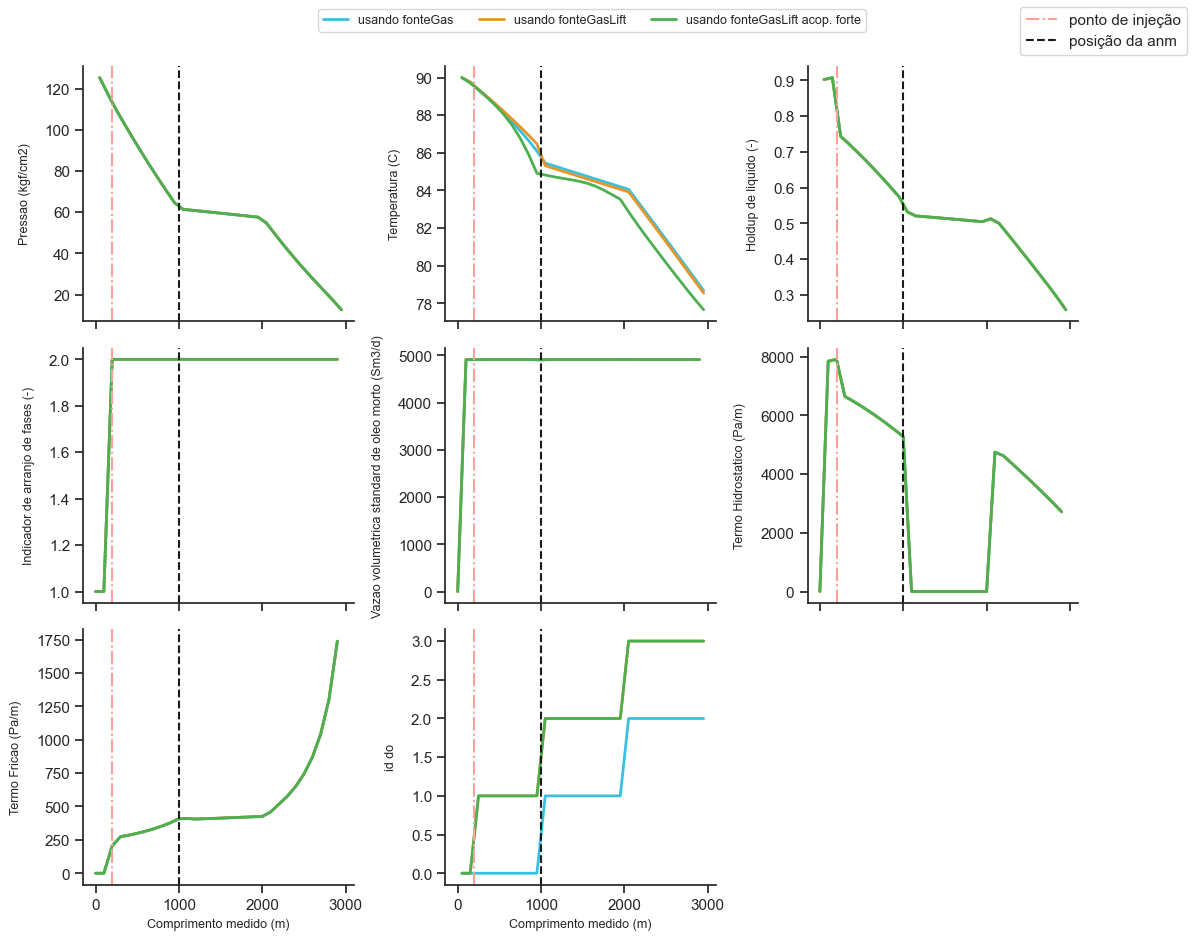

In [33]:
fig, axes = comparacao_fontes.plotar_perfis()

for ax in axes:
    injecao = ax.axvline(caso_base.fonteGas[0]['comprimentoMedido'], c='r', label='ponto de injeção', ls='-.')
    anm = ax.axvline(caso_base.master1['comprimentoMedido'], c='k', label='posição da anm', ls='--')

fig.legend([injecao, anm], ['ponto de injeção', 'posição da anm'], loc='upper right');

Note que, de maneira geral, os perfis são bem semelhantes nos três casos analisados, o que indica que a abordagem simplificada de considerar uma fonte de gás, em vez de incluir a linha de serviço com válvula, é adequada. Entretanto, o perfil de temperatura no caso em que se considera a linha de serviço e um acoplamento térmico forte entre a coluna e o espaço anular apresenta uma diferença significativa. Portanto, o cálculo do acoplamento térmico forte deve ser efetuado em cenários em que a previsão acurada do perfil de temperatura é importante, especialmente nas proximidades da árvore de natal.

Podemos também comparar os perfis na linha de serviço:

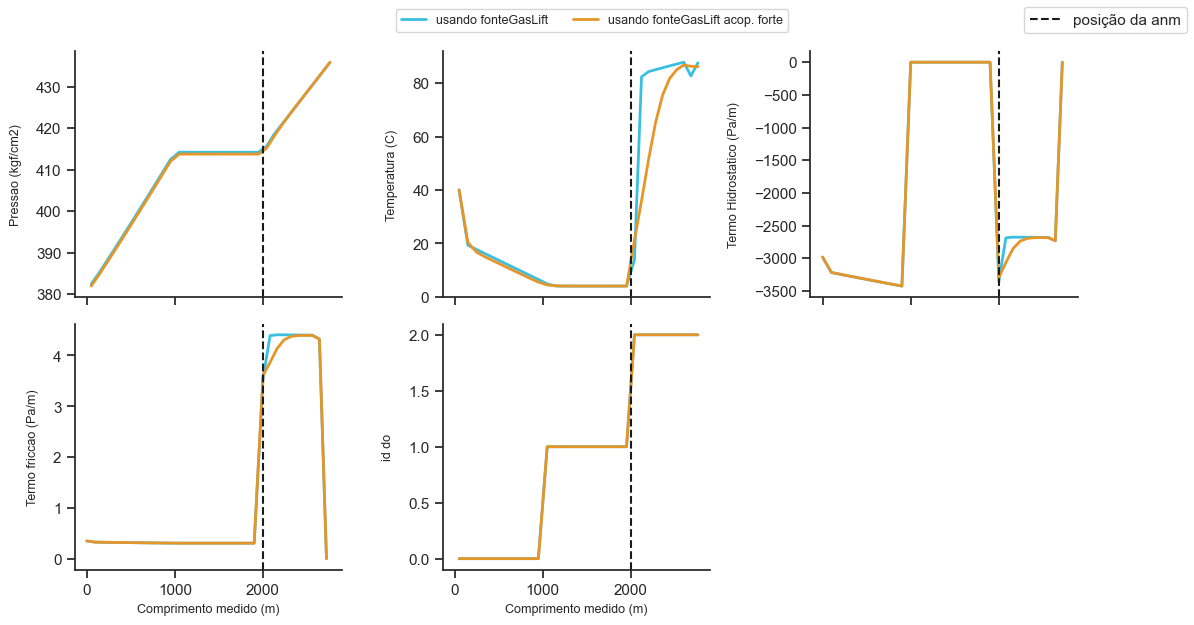

In [34]:
comparacao_fontes_servico = marlim3.Cenarios({'usando fonteGasLift': caso_base_vgl,
                                              'usando fonteGasLift acop. forte': caso_vgl_acop_forte})

fig, axes = comparacao_fontes_servico.plotar_perfis(linha = 'servico')

for ax in axes:
    anm = ax.axvline(2000, c='k', label='posição da anm', ls='--')

fig.legend([anm], ['posição da anm'], loc='upper right');

Perceba como o caso usando acoplamento térmico forte resulta em uma subida mais suave da temperatura do gás na linha de serviço, em uma representação mais acurada do fenômeno físico.

## Analisando impacto do tipo de válvula de *gas lift*

Nos exemplos que analisamos até agora, foi utilizada uma válvula do tipo orifício, que funciona usando um modelo clássico de bocal convergente. O [Marlim 3](https://github.com/petrobras/marlim3) também possibilita o uso de válvulas do tipo Venturi, que utiliza um modelo do tipo convergente-divergente. Isso introduz vantagens por conta de mudanças na condição operacional em que ocorre o escoamento crítico na garganta da válvula. A figura a seguir demonstra a diferença entre as duas geometrias. Para mais detalhes, consultar [ALMEIDA (2020)](https://www.semanticscholar.org/paper/VENTURI-GAS-LIFT-VALVE%3A-THEORY-AND-PRACTICE-Almeida/1cf384fe8aa7755336acbebb91f563f0c35a7522).

<div style="text-align: center;">
    <img src="https://figures.semanticscholar.org/1cf384fe8aa7755336acbebb91f563f0c35a7522/4-Figure3-1.png" alt="Texto alternativo" width="400" height="300">
</div>

No escoamento crítico, a velocidade de escoamento em dada região se torna igual à velocidade de propagação do som. Quando essa condição é atingida, diz-que o escoamento está estrangulado. A consequência é que não ocorre a propagação de informação de pressão de jusante para montante da região considerada. Dessa maneira, qualquer alteração na pressão a jusante (por exemplo, diminuição do seu valor) não é percebida pela condição de escoamento a montante. 

Considerando uma válvula de *gas lift*, existe uma condição de escoamento crítico definida pela razão crítica entre a pressão a montante (anular) e a jusante (garganta da válvula), decorrente de relações termodinâmicas. Na válvula de orifício, por conta de sua geometria, na condição de escoamento crítico essa razão é praticamente igual à razão entre pressões no anular e na coluna. Isso ocorre porque não há recuperação de pressão relevante da garganta da válvula até a coluna.

A mágica da válvula Venturi se baseia justamente nesse ponto: possibilitar na região do difusor (geometria divergente) uma recuperação da pressão, fazendo com que a razão entre pressões na coluna e no anular em que ocorre a condição crítica na garganta seja maior do que a razão ditada pela termodinâmica. Ou seja, para uma mesma pressão no anular, a pressão na coluna necessária para se atingir a vazão crítica (máxima) será maior em comparação à válvula de orifício. Da mesma maneira, a pressão no anular da válvula Venturi para uma mesma pressão na coluna, em comparação à válvula de orifício, será menor. Esse último efeito é o que será visualizado na próxima simulação.

In [35]:
%%time
caso_vgl_orificio = copy.deepcopy(caso_base_vgl)
caso_vgl_venturi = copy.deepcopy(caso_base_vgl)

caso_vgl_venturi.fonteGasLift[0]['tipoValvula'] = 2 # venturi

caso_vgl_venturi.simular()

comparacao_orificio_venturi = marlim3.Cenarios({'orificio': caso_vgl_orificio, 'venturi': caso_vgl_venturi})

*******************************************************************************
                                  UFA!!!!!!!!                                  
O sucesso nao e uma linha reta, e um jogo de resistencia, e cada tropeço e apenas um degrau a mais para a vitoria!
                                    Mario Pascal do Insta                               
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

CPU times: total: 15.6 ms
Wall time: 5.81 s


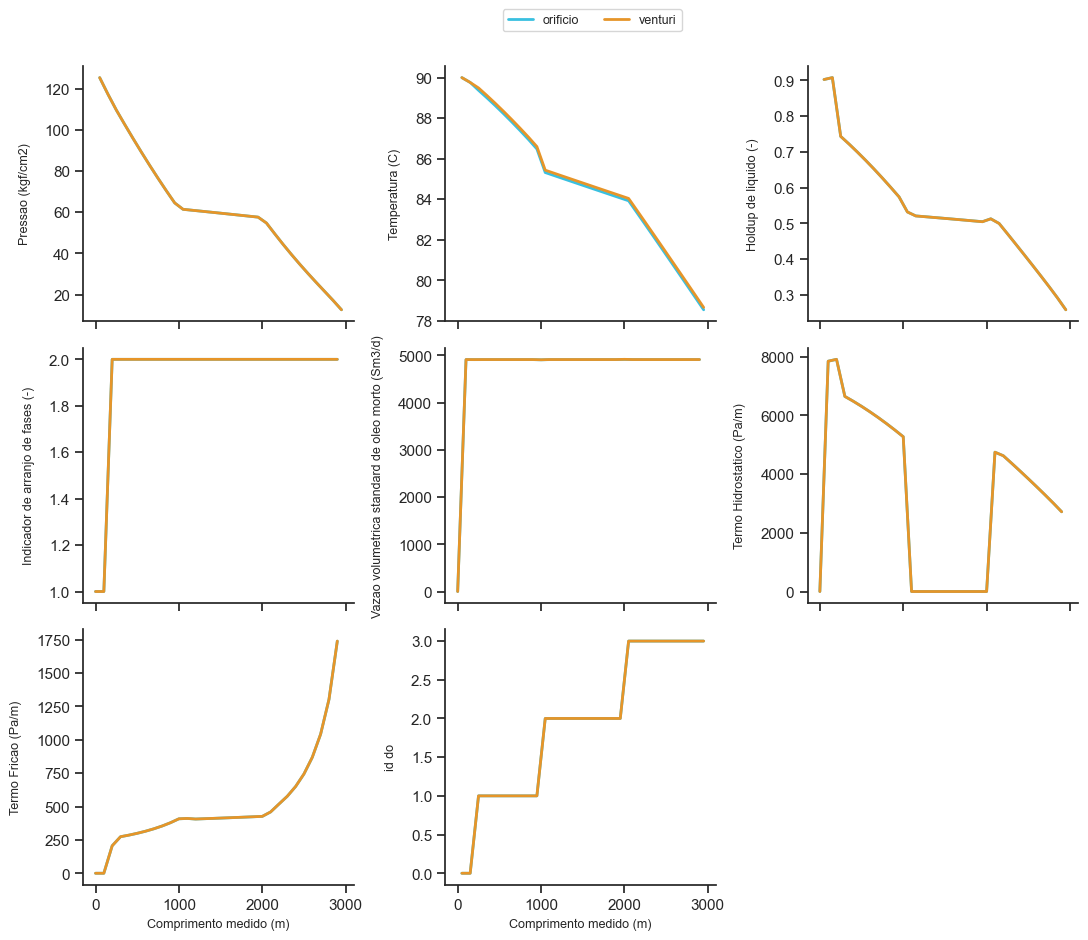

In [36]:
comparacao_orificio_venturi.plotar_perfis();

Nada de mudanças nos perfis da linha de produção. Já ao observar a linha de serviço...

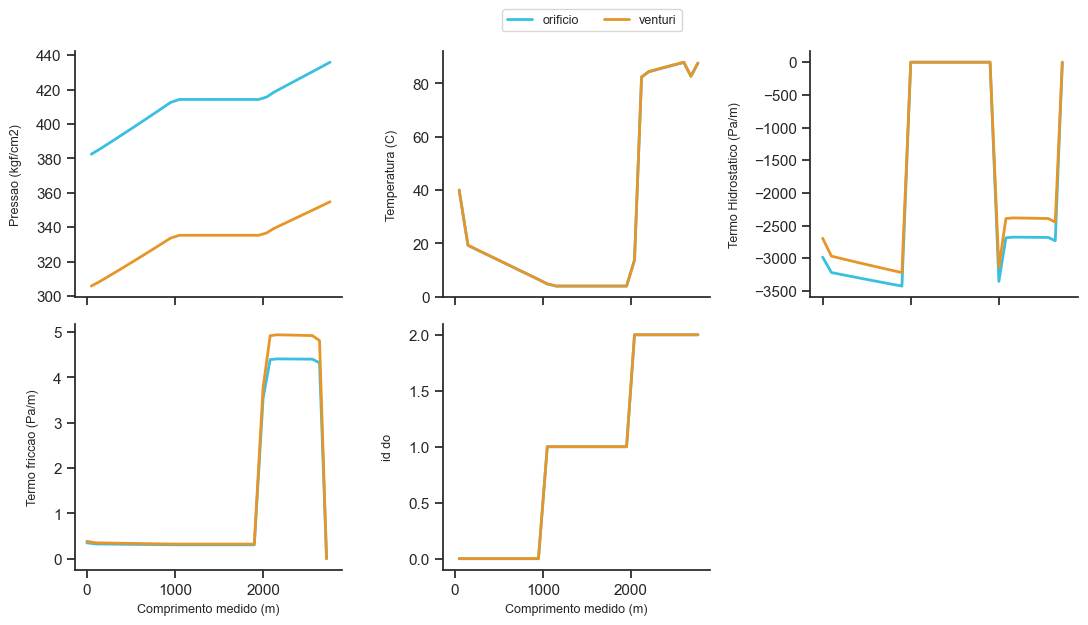

In [37]:
comparacao_orificio_venturi.plotar_perfis(linha='servico');

A pressão no anular do caso com válvula Venturi, associada à mesma condição de produção, é significativamente menor! Isso significa que os dois casos estão com escoamento crítico na garganta da válvula, e no caso da válvula Venturi, esta condição é atingida com pressão de injeção menor. Gasta-se, portanto, menos energia no sistema de injeção de gás para se alcançar o mesmo desempenho.

## Salvando o caso base

No comando abaixo, salvamos o caso base em um JSON para poder importá-lo no próximo tutorial.

In [38]:
caso_base_vgl.to_json('caso_base_vgl_tutoriais')

## Faça você também!!

1. Altere a condição de contorno de injeção de gás no modelo `caso_vgl_venturi`, substituindo a condição do tipo vazão por uma condição do tipo pressão. Para isso, será necessário modificar os parâmetros do objeto `gasInj`. Utilize como pressão de injeção o valor obtido na simulação anterior, que empregou a condição do tipo vazão. Verifique se a vazão resultante é igual àquela definida anteriormente, como esperado. Em seguida, compare os tempos de execução das duas simulações. Eles são diferentes? Por quê?

2. Repita o mesmo procedimento utilizando o modelo `caso_vgl_orificio`, mas ainda usando a pressão de injeção do caso com válvula Venturi. A vazão resultante é maior ou menor do que a verificada no item anterior? Por quê?